# 1주차 - 전처리와 randomforest 모델 구현

In [98]:
import pandas as pd

In [99]:
df = pd.read_csv("dataset.csv")

print(df)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  former

In [100]:
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [101]:
print(df.shape)

(5110, 12)


In [102]:
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [103]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [104]:
print(df["bmi"].isnull().sum())

bmi_mean = df["bmi"].mean()
df["bmi"] = df["bmi"].fillna(bmi_mean)

print(df["bmi"].isnull().sum())

201
0


bmi에 결측값이 있었음. 그래서 처음에는 모든 값을 0으로 바꿔서 결측치를 제거했으나, 오류가 생겨서 mean 값으로 결측치를 대체하였음

In [105]:
print(df["stroke"].value_counts())
print(df["stroke"].value_counts)

stroke
0    4861
1     249
Name: count, dtype: int64
<bound method IndexOpsMixin.value_counts of 0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64>


데이터를 봤을 때, 뇌졸증에 걸리지 않은 사람이 걸린 사람보다 훨씬 많았음.
편향된 데이터라서, 정확도 판별할 때 주의해야함.

In [106]:
import matplotlib.pyplot as plt

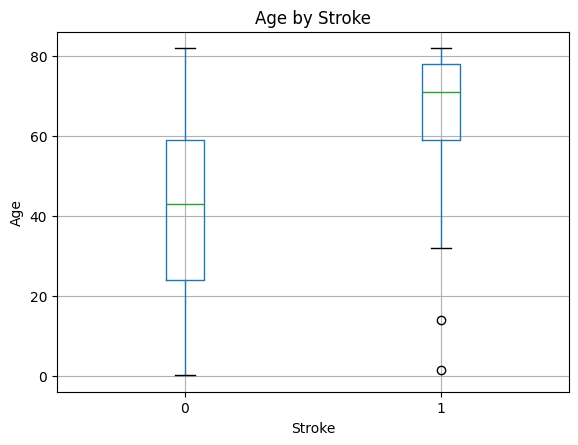

In [107]:
df.boxplot(column="age", by="stroke")
plt.title("Age by Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.show()

나이와 뇌졸증을 비교해봤을 때, 나이가 많은 사람이 뇌졸증에 걸릴 확률이 높다는 것을 알았다.
(나이와 뇌졸증의 변수 관계가 높다고 생각할 수 있음)

In [108]:
df['gender'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})

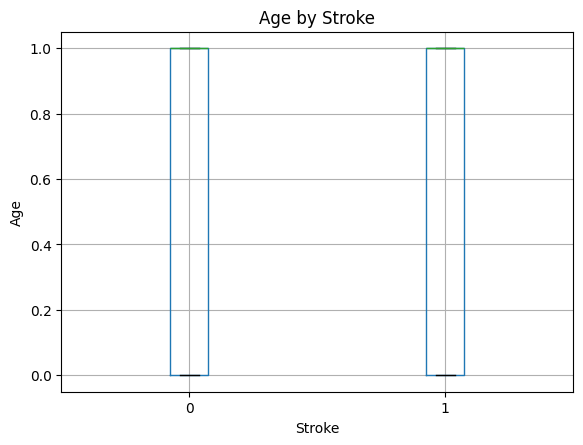

In [109]:
df.boxplot(column="gender", by="stroke")
plt.title("Age by Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.show()

성별과 뇌졸증은 별로 관계가 없다.

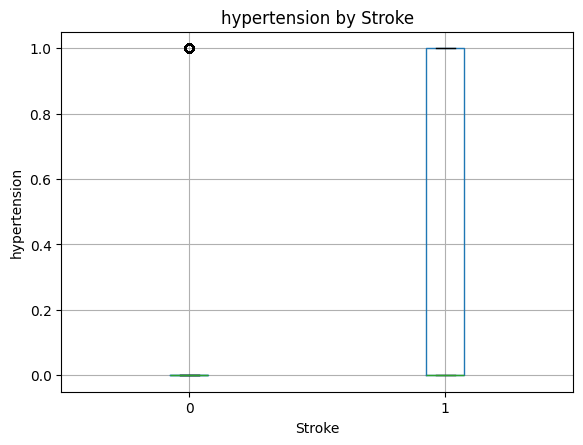

In [110]:
df.boxplot(column="hypertension", by="stroke")
plt.title("hypertension by Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("hypertension")
plt.show()

고혈압에 걸린 환자들은 거의 다 뇌졸증에 걸리는가?

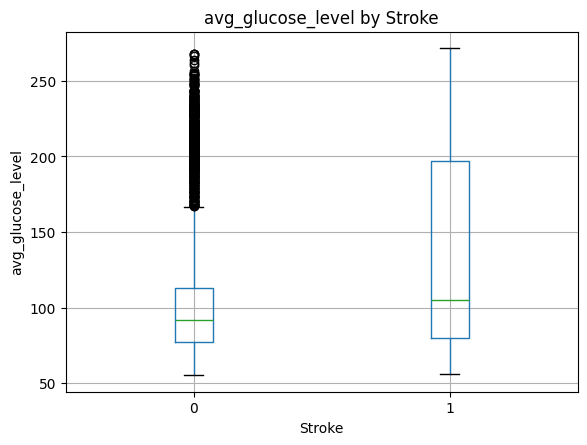

In [111]:
df.boxplot(column="avg_glucose_level", by="stroke")
plt.title("avg_glucose_level by Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("avg_glucose_level")
plt.show()

혈당과의 관계는 결측치가 많았다.

In [112]:
df = df.drop("id", axis=1)
print(df.head())

   gender   age  hypertension  heart_disease ever_married      work_type  \
0     0.0  67.0             0              1          Yes        Private   
1     1.0  61.0             0              0          Yes  Self-employed   
2     0.0  80.0             0              1          Yes        Private   
3     1.0  49.0             0              0          Yes        Private   
4     1.0  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level        bmi   smoking_status  stroke  
0          Urban             228.69  36.600000  formerly smoked       1  
1          Rural             202.21  28.893237     never smoked       1  
2          Rural             105.92  32.500000     never smoked       1  
3          Urban             171.23  34.400000           smokes       1  
4          Rural             174.12  24.000000     never smoked       1  


id 는 필요없는 값이라서 제거

In [113]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

print(X.head())
print(y.head())

   gender   age  hypertension  heart_disease ever_married      work_type  \
0     0.0  67.0             0              1          Yes        Private   
1     1.0  61.0             0              0          Yes  Self-employed   
2     0.0  80.0             0              1          Yes        Private   
3     1.0  49.0             0              0          Yes        Private   
4     1.0  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level        bmi   smoking_status  
0          Urban             228.69  36.600000  formerly smoked  
1          Rural             202.21  28.893237     never smoked  
2          Rural             105.92  32.500000     never smoked  
3          Urban             171.23  34.400000           smokes  
4          Rural             174.12  24.000000     never smoked  
0    1
1    1
2    1
3    1
4    1
Name: stroke, dtype: int64


stroke는 예측해야하는 값으로 y로 빼야하기 때문에 x에서 분리하였음

In [114]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())
print(X.shape)

   gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0     0.0  67.0             0              1             228.69  36.600000   
1     1.0  61.0             0              0             202.21  28.893237   
2     0.0  80.0             0              1             105.92  32.500000   
3     1.0  49.0             0              0             171.23  34.400000   
4     1.0  79.0             1              0             174.12  24.000000   

   ever_married_Yes  work_type_Never_worked  work_type_Private  \
0              True                   False               True   
1              True                   False              False   
2              True                   False               True   
3              True                   False               True   
4              True                   False              False   

   work_type_Self-employed  work_type_children  Residence_type_Urban  \
0                    False               False                

결측치를 제거하였음

In [115]:
import pandas as pd
import numpy as np

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3577, 15)
(1533, 15)
(3577,)
(1533,)


훈련셋과 테스트셋을 분리하였음

In [117]:
print(X_train.isnull().sum())

gender                            0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64


In [118]:
print(X_test.isnull().sum())

gender                            1
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64


X test에 있는 데이터셋에서 age 결측값이 발생하였음. -> 제거

In [119]:
X_test = X_test.dropna()
y_test = y_test[X_test.index]

X test 값을 지웠으므로, y test 값 수를 X test 수와 맞춰주었음

In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)


In [121]:
print (lr_acc)

0.9425587467362925


In [122]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)

print(lr_cm)

[[1443    0]
 [  88    1]]


In [123]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1443
           1       1.00      0.01      0.02        89

    accuracy                           0.94      1532
   macro avg       0.97      0.51      0.50      1532
weighted avg       0.95      0.94      0.92      1532



## 2주차 - 여러 모델 사용 및 정확도 높이기

In [124]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier (random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score (y_test, dt_pred)

print(dt_acc)

0.9046997389033943


In [125]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[1371   72]
 [  74   15]]


In [126]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1443
           1       0.17      0.17      0.17        89

    accuracy                           0.90      1532
   macro avg       0.56      0.56      0.56      1532
weighted avg       0.90      0.90      0.90      1532



In [127]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(rf_acc)

0.9412532637075718


In [128]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1443
           1       0.00      0.00      0.00        89

    accuracy                           0.94      1532
   macro avg       0.47      0.50      0.48      1532
weighted avg       0.89      0.94      0.91      1532



In [129]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print(knn_acc)

0.9360313315926893


In [130]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1443
           1       0.15      0.02      0.04        89

    accuracy                           0.94      1532
   macro avg       0.55      0.51      0.50      1532
weighted avg       0.90      0.94      0.91      1532



In [131]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, ada_pred)

print(ada_acc)

0.9419060052219321


In [132]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1443
           1       0.00      0.00      0.00        89

    accuracy                           0.94      1532
   macro avg       0.47      0.50      0.49      1532
weighted avg       0.89      0.94      0.91      1532



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [133]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(xgb_acc)

0.9386422976501305


In [134]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1443
           1       0.35      0.07      0.11        89

    accuracy                           0.94      1532
   macro avg       0.65      0.53      0.54      1532
weighted avg       0.91      0.94      0.92      1532



### 모델 조정 (balanced를 중심으로)

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print(lr_acc)

0.7460835509138382


In [136]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1443
           1       0.15      0.73      0.25        89

    accuracy                           0.75      1532
   macro avg       0.56      0.74      0.55      1532
weighted avg       0.93      0.75      0.81      1532



In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_acc)

Accuracy: 0.7114882506527415


In [138]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.71      0.82      1443
           1       0.14      0.81      0.25        89

    accuracy                           0.71      1532
   macro avg       0.56      0.76      0.53      1532
weighted avg       0.93      0.71      0.79      1532



In [139]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))
print("Classification Report")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7754569190600522
Confusion Matrix
[[1127  316]
 [  28   61]]
Classification Report
              precision    recall  f1-score   support

           0       0.98      0.78      0.87      1443
           1       0.16      0.69      0.26        89

    accuracy                           0.78      1532
   macro avg       0.57      0.73      0.56      1532
weighted avg       0.93      0.78      0.83      1532



In [140]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)
print("Confusion Matrix")
print(confusion_matrix(y_test, knn_pred))
print("Classification Report")
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9360313315926893
Confusion Matrix
[[1434    9]
 [  89    0]]
Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1443
           1       0.00      0.00      0.00        89

    accuracy                           0.94      1532
   macro avg       0.47      0.50      0.48      1532
weighted avg       0.89      0.94      0.91      1532



In [141]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.8,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

ada_acc = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_acc)
print("Confusion Matrix")
print(confusion_matrix(y_test, ada_pred))
print("Classification Report")
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy: 0.9419060052219321
Confusion Matrix
[[1443    0]
 [  89    0]]
Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1443
           1       0.00      0.00      0.00        89

    accuracy                           0.94      1532
   macro avg       0.47      0.50      0.49      1532
weighted avg       0.89      0.94      0.91      1532



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [142]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=20,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)
print("Confusion Matrix")
print(confusion_matrix(y_test, xgb_pred))
print("Classification Report")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7950391644908616
Confusion Matrix
[[1155  288]
 [  26   63]]
Classification Report
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      1443
           1       0.18      0.71      0.29        89

    accuracy                           0.80      1532
   macro avg       0.58      0.75      0.58      1532
weighted avg       0.93      0.80      0.85      1532



In [143]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

result = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest",
        "AdaBoost",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, ada_pred,),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, dt_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, ada_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1-score": [
        f1_score(y_test, dt_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, ada_pred),
        f1_score(y_test, xgb_pred)
    ]
})

print(result)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


           Model  Accuracy  Precision    Recall  F1-score
0  Decision Tree  0.775457   0.161804  0.685393  0.261803
1            KNN  0.936031   0.000000  0.000000  0.000000
2  Random Forest  0.711488   0.144869  0.808989  0.245734
3       AdaBoost  0.941906   0.000000  0.000000  0.000000
4        XGBoost  0.795039   0.179487  0.707865  0.286364


knn 모델과 adaboost는 다른 모델에 비해 현저히 정확도가 높게 측정됐지만, precision, recall, f1score 점수가 0이었다. 이는 좋은 모델이라고 할 수 없기 때문에 결과 비교에서 제외했다.
나머지 비교 모델 decision tree, randomforest, xgboost 중에서는, xgboost가 정확도 뿐만 아니라, precision, recall, f1score 모두 높았기 때문에, 가장 좋은 모델이라고 생각했다.. ....